Librerias necesarias

In [ ]:
from selenium import webdriver
from selenium.webdriver.edge.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

# CONFIG EDGE

options = Options()
options.add_argument("--headless")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Edge(options=options)
wait = WebDriverWait(driver, 30)

BASE_URL = "https://admision.unmsm.edu.pe/Website20261/A/A.html"


# OBTENCIÓN DE LAS ESCUELAS

driver.get(BASE_URL)
wait.until(EC.presence_of_element_located((By.TAG_NAME, "a")))

escuelas = []
for a in driver.find_elements(By.TAG_NAME, "a"):
    texto = a.text.strip()
    href = a.get_attribute("href")
    if texto and href and href.endswith(".html"):
        escuelas.append((texto, href))

print(f"Escuelas encontradas: {len(escuelas)}")


# SCRAPING

resultados = []

for escuela, link in escuelas:
    print(f"Procesando: {escuela}")
    driver.get(link)

    try:
        
        wait.until(EC.presence_of_element_located((By.ID, "tablaPostulantes_wrapper")))
    except:
        print("No hay tabla en esta página")
        continue

    time.sleep(1)

      #Mostrar todos los registros
    driver.execute_script("""
        if ($.fn.DataTable.isDataTable('#tablaPostulantes')) {
            $('#tablaPostulantes').DataTable().page.len(-1).draw();
        }
    """)

    time.sleep(2)

    filas = driver.find_elements(By.CSS_SELECTOR, "#tablaPostulantes tbody tr")

    for fila in filas:
        celdas = fila.find_elements(By.TAG_NAME, "td")
        if len(celdas) < 6:
            continue

        resultados.append({
            "codigo": celdas[0].text.strip(),
            "nombre_apellido": celdas[1].text.strip(),
            "escuela": celdas[2].text.strip(),
            "puntaje": celdas[3].get_attribute("data-score"),
            "orden_merito": celdas[4].get_attribute("data-merit"),
            "observacion": celdas[5].text.strip()
        })

driver.quit()


# GUARDAR RESULTADOS

df = pd.DataFrame(resultados)

print(f"Total registros extraídos: {len(df)}")

df.to_csv("resultados_admision_unmsm.csv", index=False, encoding="utf-8-sig")
df.to_excel("resultados_admision_unmsm.xlsx", index=False)

print("SCRAPING COMPLETADO. Resultados guardados en CSV y Excel.")






Escuelas encontradas: 96
Procesando: Inicio
No hay tabla en esta página
Procesando: ADMINISTRACIÓN - HUARAL
Procesando: ADMINISTRACIÓN - LIMA
Procesando: ADMINISTRACIÓN - S.J.L
Procesando: ADMINISTRACIÓN DE LA GASTRONOMÍA
Procesando: ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES - HUARAL
Procesando: ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES - LIMA
Procesando: ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES - S.J.L
Procesando: ADMINISTRACIÓN DE TURISMO - HUARAL
Procesando: ADMINISTRACIÓN DE TURISMO - LIMA
Procesando: ADMINISTRACIÓN DE TURISMO - S.J.L
Procesando: ADMINISTRACIÓN MARÍTIMA Y PORTUARIA
Procesando: ADMINISTRACION MARITIMA Y PORTUARIA - HUARAL
Procesando: ANTROPOLOGÍA
Procesando: ARQUEOLOGÍA
Procesando: ARQUITECTURA Y URBANISMO
Procesando: ARTE
Procesando: AUDITORÍA EMPRESARIAL Y DEL SECTOR PÚBLICO - LIMA
Procesando: AUDITORÍA EMPRESARIAL Y DEL SECTOR PÚBLICO - S.J.L
Procesando: BIBLIOTECOLOGÍA Y CIENCIAS DE LA INFORMACIÓN
Procesando: CIENCIA DE LA COMPUTACIÓN
Procesando: CIENCIA POL

Importando el cvs

In [ ]:
df_unmsm = pd.read_csv('resultados_admision_unmsm.csv')
df_unmsm.head(20)

,codigo,nombre_apellido,escuela,puntaje,orden_merito,observacion
0,552493,"ANDAGUA GAMBOA, DALESKA MARTHA ESPERANZA",ADMINISTRACIÓN - HUARAL,560.625,9.0,ALCANZÓ VACANTE
1,570362,"BEZARES VILLAVERDE, JETLI",ADMINISTRACIÓN - HUARAL,923.750,1.0,ALCANZÓ VACANTE
2,591588,"FLORES PIMENTEL, LEONARDO CRISTOFER",ADMINISTRACIÓN - HUARAL,869.875,2.0,ALCANZÓ VACANTE
3,580332,"GARCIA CABELLO, PIEERS AXEL",ADMINISTRACIÓN - HUARAL,779.750,4.0,ALCANZÓ VACANTE
4,564185,"PALACIOS RAMÍREZ, JOSUÉ ANTONIO",ADMINISTRACIÓN - HUARAL,855.750,3.0,ALCANZÓ VACANTE
5,561061,"PROSOPIO ALARCON, JUAN PABLO",ADMINISTRACIÓN - HUARAL,530.375,NaN,NaN
6,564067,"QUISPE LLIUYA, JULIO RODRIGO",ADMINISTRACIÓN - HUARAL,724.500,5.0,ALCANZÓ VACANTE
7,563817,"RAFAEL SIMON, YASMIN MELANY",ADMINISTRACIÓN - HUARAL,595.250,8.0,ALCANZÓ VACANTE
8,572939,"SIFUENTES HURTADO, HUBELINDA",ADMINISTRACIÓN - HUARAL,612.000,7.0,ALCANZÓ VACANTE
9,569929,"SINARAHUA TAPULLIMA, ADOLFO HITLER",ADMINISTRACIÓN - HUARAL,534.750,10.0,ALCANZÓ VACANTE


Informacion general del admision 2026-I

In [ ]:
df_unmsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26518 entries, 0 to 26517
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   codigo           26518 non-null  int64  
 1   nombre_apellido  26518 non-null  object 
 2   escuela          26518 non-null  object 
 3   puntaje          26179 non-null  float64
 4   orden_merito     2772 non-null   float64
 5   observacion      3111 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 1.2+ MB


In [ ]:
df_unmsm['codigo'] = df_unmsm['codigo'].astype('str')

df_unmsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26518 entries, 0 to 26517
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   codigo           26518 non-null  object 
 1   nombre_apellido  26518 non-null  object 
 2   escuela          26518 non-null  object 
 3   puntaje          26179 non-null  float64
 4   orden_merito     2772 non-null   float64
 5   observacion      3111 non-null   object 
dtypes: float64(2), object(4)
memory usage: 1.2+ MB


Rsumen estadistico del dataset

In [ ]:
df_unmsm.describe()

,puntaje,orden_merito
count,26179.000000,2772.000000
mean,805.517561,22.882395
std,202.755801,21.905539
min,144.500000,1.000000
25%,661.125000,8.000000
50%,790.125000,16.000000
75%,933.750000,31.000000
max,1679.125000,136.000000


In [ ]:
#nulos
df_unmsm.isna().sum()

codigo                 0
nombre_apellido        0
escuela                0
puntaje              339
orden_merito       23746
observacion        23407
dtype: int64

In [ ]:
#Limpiando datos
df_unmsm["observacion"] = df_unmsm["observacion"].fillna("NO ALACANZÓ VACANTE")
df_unmsm.isna().sum()


codigo                 0
nombre_apellido        0
escuela                0
puntaje              339
orden_merito       23746
observacion            0
dtype: int64

In [ ]:
#Numero de postulantes por escuela
df_unmsm['escuela'].value_counts()

escuela
MEDICINA HUMANA                                       4709
DERECHO                                               2140
PSICOLOGÍA                                            1164
INGENIERÍA DE SISTEMAS                                1033
ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES - LIMA      929
                                                      ... 
ADMINISTRACIÓN DE TURISMO - HUARAL                      18
PRESUPUESTO Y FINANZAS PÚBLICAS - S.J.L                 18
AUDITORÍA EMPRESARIAL Y DEL SECTOR PÚBLICO - S.J.L      12
ADMINISTRACIÓN - HUARAL                                 11
DANZA                                                   10
Name: count, Length: 95, dtype: int64

In [ ]:
#columna para entrenar modelo
def clasificador_observacion(observacion):
    if observacion == 'ALCANZÓ VACANTE':
        return 1
    elif observacion == 'AUSENTE':
        return 2
    else:
        return 0

df_unmsm['clasificacion'] = df_unmsm['observacion'].apply(clasificador_observacion)
df_unmsm.head(20)

,codigo,nombre_apellido,escuela,puntaje,orden_merito,observacion,clasificacion
0,552493,"ANDAGUA GAMBOA, DALESKA MARTHA ESPERANZA",ADMINISTRACIÓN - HUARAL,560.625,9.0,ALCANZÓ VACANTE,1
1,570362,"BEZARES VILLAVERDE, JETLI",ADMINISTRACIÓN - HUARAL,923.750,1.0,ALCANZÓ VACANTE,1
2,591588,"FLORES PIMENTEL, LEONARDO CRISTOFER",ADMINISTRACIÓN - HUARAL,869.875,2.0,ALCANZÓ VACANTE,1
3,580332,"GARCIA CABELLO, PIEERS AXEL",ADMINISTRACIÓN - HUARAL,779.750,4.0,ALCANZÓ VACANTE,1
4,564185,"PALACIOS RAMÍREZ, JOSUÉ ANTONIO",ADMINISTRACIÓN - HUARAL,855.750,3.0,ALCANZÓ VACANTE,1
5,561061,"PROSOPIO ALARCON, JUAN PABLO",ADMINISTRACIÓN - HUARAL,530.375,NaN,NO ALACANZÓ VACANTE,0
6,564067,"QUISPE LLIUYA, JULIO RODRIGO",ADMINISTRACIÓN - HUARAL,724.500,5.0,ALCANZÓ VACANTE,1
7,563817,"RAFAEL SIMON, YASMIN MELANY",ADMINISTRACIÓN - HUARAL,595.250,8.0,ALCANZÓ VACANTE,1
8,572939,"SIFUENTES HURTADO, HUBELINDA",ADMINISTRACIÓN - HUARAL,612.000,7.0,ALCANZÓ VACANTE,1
9,569929,"SINARAHUA TAPULLIMA, ADOLFO HITLER",ADMINISTRACIÓN - HUARAL,534.750,10.0,ALCANZÓ VACANTE,1


In [ ]:
#Maximo y minimo puntaje por escuela
df_unmsm.groupby('escuela')['puntaje'].agg(['max', 'min'])

,max,min
escuela,,
ADMINISTRACION MARITIMA Y PORTUARIA - HUARAL,975.625,342.500
ADMINISTRACIÓN - HUARAL,923.750,530.375
ADMINISTRACIÓN - LIMA,1265.750,338.000
ADMINISTRACIÓN - S.J.L,972.750,314.500
ADMINISTRACIÓN DE LA GASTRONOMÍA,1164.125,300.375
...,...,...
TEC. MED. RADIOLOGÍA,1360.500,399.625
TEC. MED. TERAPIA FÍSICA Y REHABILITACIÓN,1429.625,183.250
TEC. MED. TERAPIA OCUPACIONAL,1189.250,499.000


In [ ]:
#Escuela con el mayor puntaje
df_unmsm.loc[df_unmsm['puntaje'].idxmax()]

codigo                                  864756
nombre_apellido    VIVANCO ALOR, RONALD JEREMY
escuela                        MEDICINA HUMANA
puntaje                               1679.125
orden_merito                               1.0
observacion                    ALCANZÓ VACANTE
clasificacion                                1
Name: 22244, dtype: object

In [ ]:
#Maximo y minimo puntaje en general
df_unmsm['puntaje'].agg(['max', 'min'])

max    1679.125
min     144.500
Name: puntaje, dtype: float64

In [ ]:
#Deteccion de duplicados
duplicados = df_unmsm.duplicated().sum()
print("El numero de filas duplicadas es: {}".format(duplicados))

El numero de filas duplicadas es: 0


In [ ]:
#Revisando si hay puntaje negativo (validacion de datos)
if (df_unmsm['puntaje'] < 0).any():
      print("Hay puntajes negativos en los datos")
else:
      print("No hay puntajes negativos en los datos")

No hay puntajes negativos en los datos


In [ ]:
#personas que alcanzaron vacante, quienes no y el numero de ausentes
df_unmsm['observacion'].value_counts()

observacion
NO ALACANZÓ VACANTE    23407
ALCANZÓ VACANTE         2772
AUSENTE                  339
Name: count, dtype: int64

In [ ]:
df_unmsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26518 entries, 0 to 26517
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   codigo           26518 non-null  object 
 1   nombre_apellido  26518 non-null  object 
 2   escuela          26518 non-null  object 
 3   puntaje          26179 non-null  float64
 4   orden_merito     2772 non-null   float64
 5   observacion      26518 non-null  object 
 6   clasificacion    26518 non-null  int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 1.4+ MB


Analisis exploratorio de datos

C:\Users\User\AppData\Local\Temp\ipykernel_23980\166578859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_unmsm, x='observacion', palette='viridis')


Text(0, 0.5, 'Postulantes')

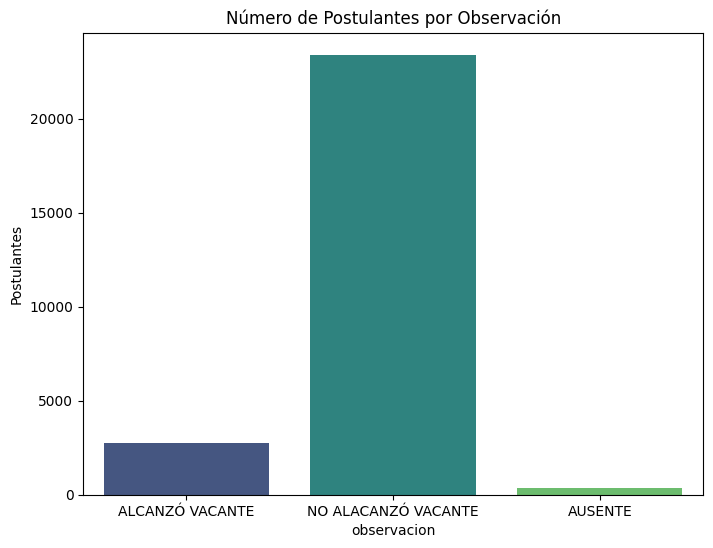

In [ ]:
#Grafico de barras de las observaciones
figure = plt.figure(figsize=(8,6))
sns.countplot(data=df_unmsm, x='observacion', palette='viridis')

plt.title('Número de Postulantes por Observación')
plt.ylabel('Postulantes')

Observamos claramente que el numero de personas que no alcanzaron vacante es mucho mayor que el numero de perosnas que si logran alcanzar una vacante

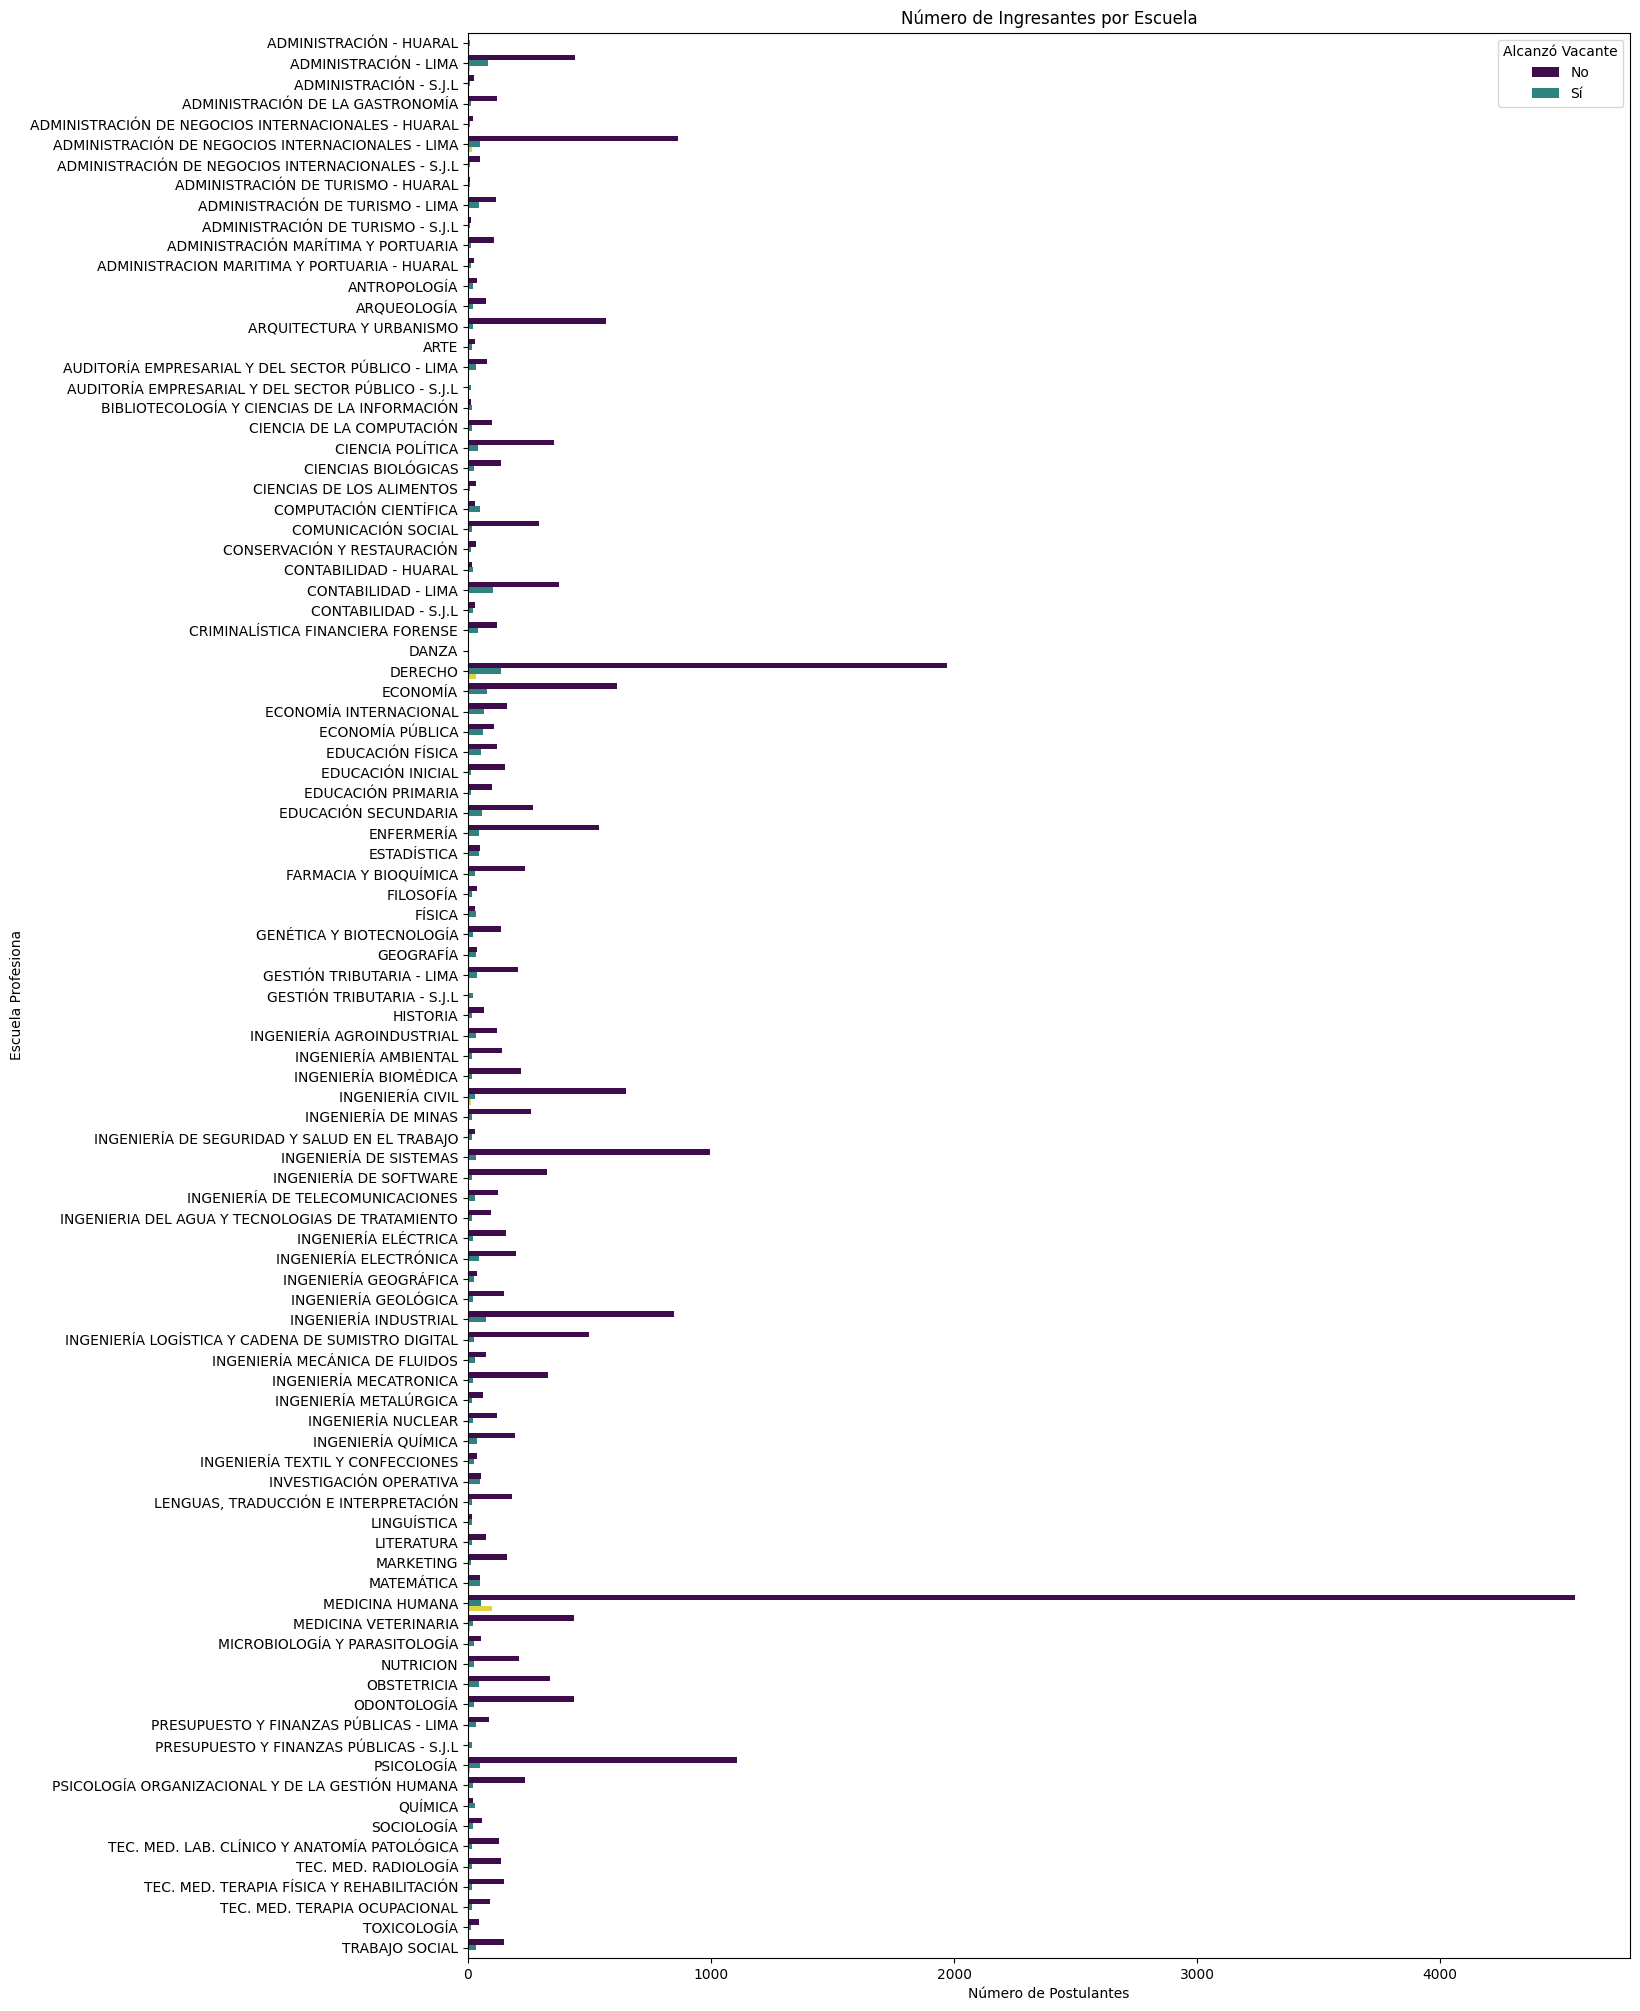

In [ ]:
#Ingresantes por escuela
plt.figure(figsize=(15, 25))
sns.countplot(data=df_unmsm, y='escuela', hue='clasificacion', palette='viridis')

plt.title('Número de Ingresantes por Escuela')
plt.ylabel('Escuela Profesiona')
plt.xlabel('Número de Postulantes')
plt.legend(title='Alcanzó Vacante', loc='upper right', labels=['No', 'Sí'])


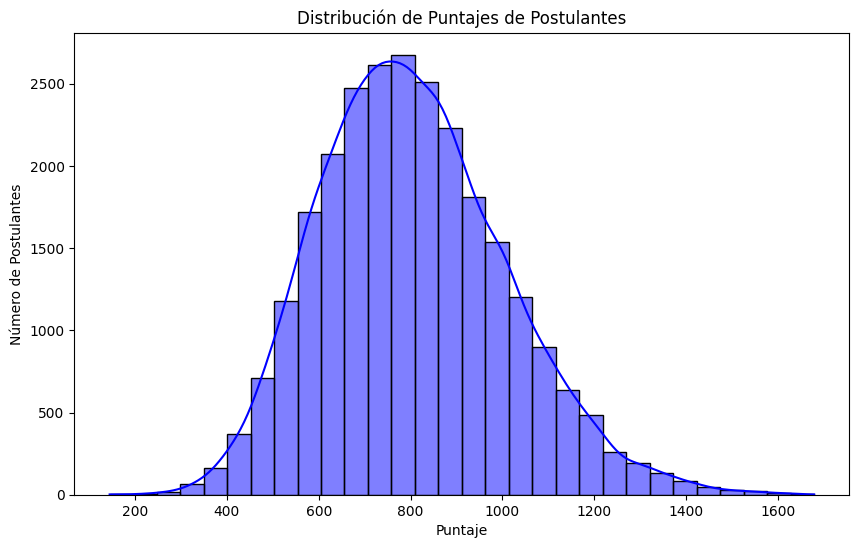

In [ ]:
#Histograma de puntajes
plt.figure(figsize=(10,6))
sns.histplot(data=df_unmsm, x='puntaje', bins=30, kde=True, color='blue')
plt.title('Distribución de Puntajes de Postulantes')  
plt.xlabel('Puntaje')
plt.ylabel('Número de Postulantes')
plt.show()

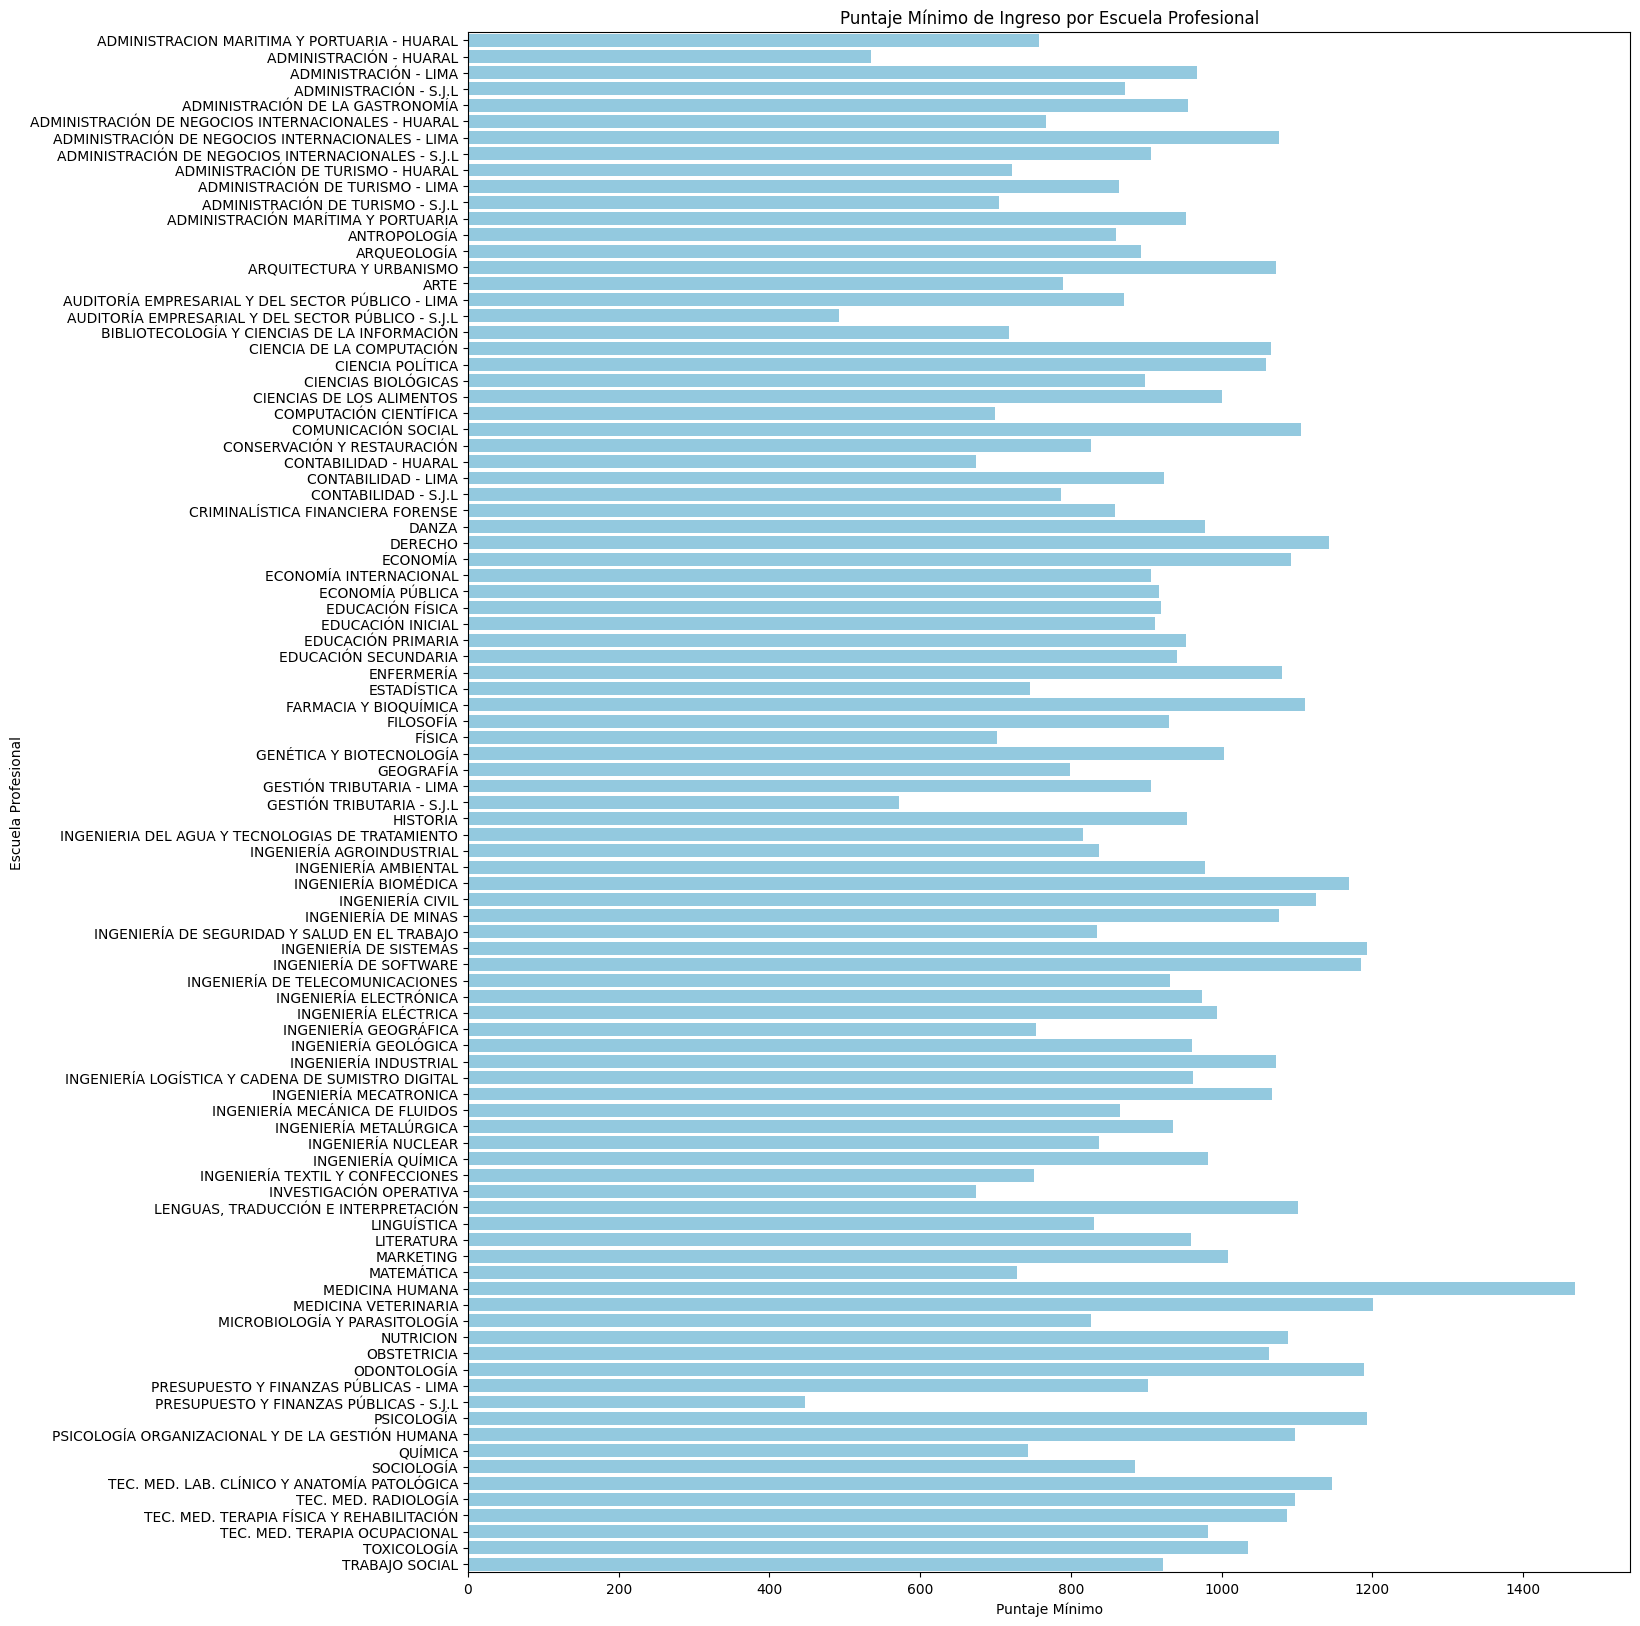

In [ ]:
#puntaje minimo de ingreso por carrera
minimo_ingreso = df_unmsm[df_unmsm['clasificacion'] == 1].groupby('escuela')['puntaje'].min()

plt.figure(figsize=(15,20))
sns.barplot(x=minimo_ingreso.values, y=minimo_ingreso.index, color='skyblue')
plt.title('Puntaje Mínimo de Ingreso por Escuela Profesional')
plt.xlabel('Puntaje Mínimo')
plt.ylabel('Escuela Profesional')
plt.show()


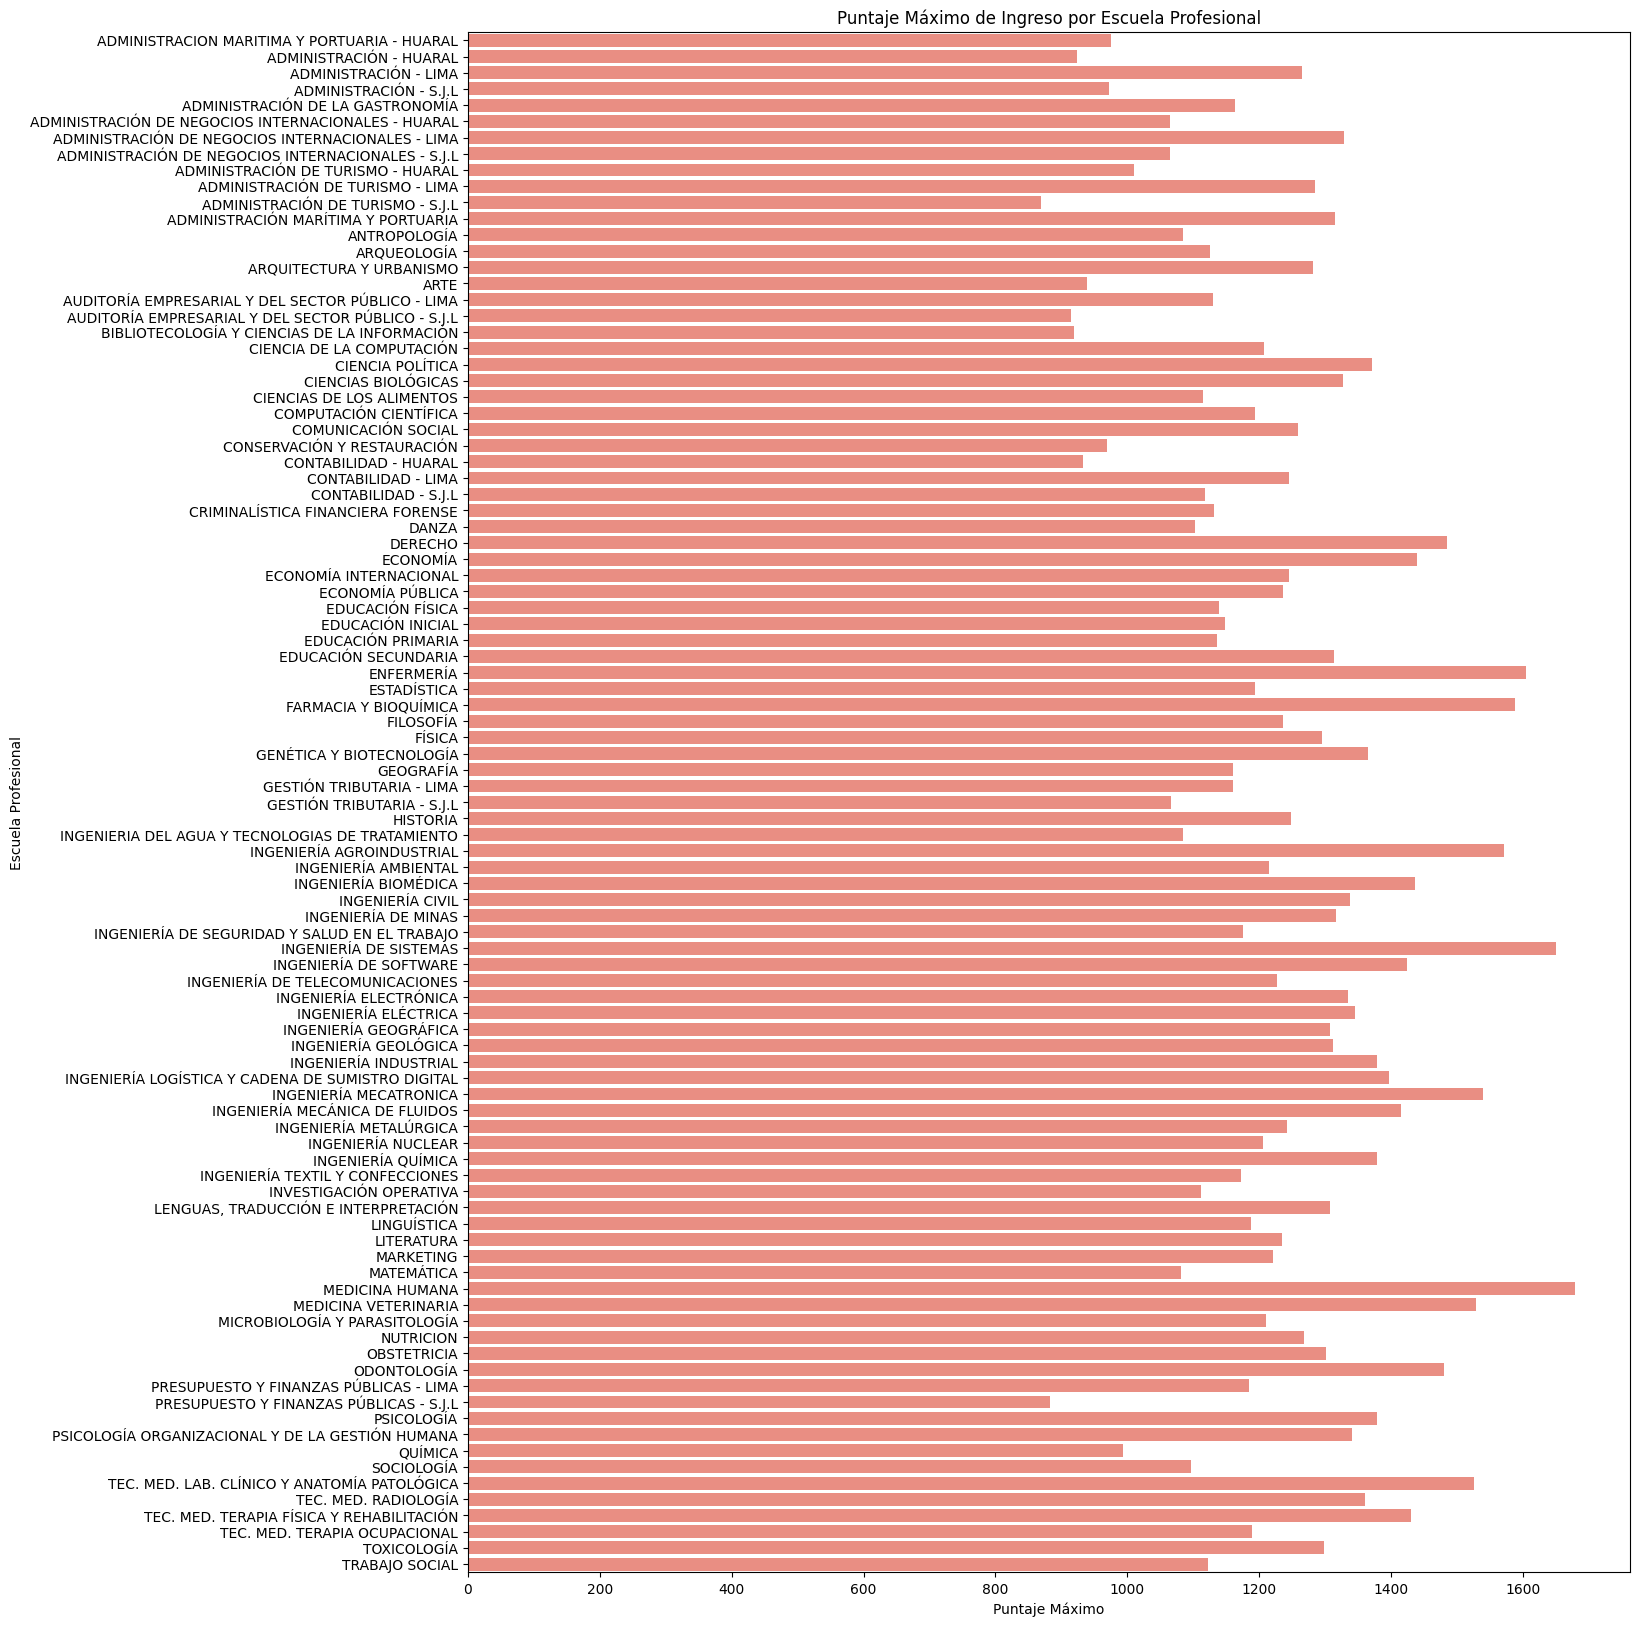

In [ ]:
#Grafica de puntajes maximos

maximo_ingreso = df_unmsm[df_unmsm['clasificacion']==1].groupby('escuela')['puntaje'].max()

plt.figure(figsize=(15,20))
sns.barplot(x=maximo_ingreso.values, y=maximo_ingreso.index, color='salmon')
plt.title('Puntaje Máximo de Ingreso por Escuela Profesional')    
plt.xlabel('Puntaje Máximo')
plt.ylabel('Escuela Profesional')
plt.show()

In [ ]:
#TOP 10 PERSONAS CON MAYOR PUNTAJE
top_10 = df_unmsm[df_unmsm['clasificacion']==1].groupby('nombre_apellido')['puntaje'].max().sort_values(ascending=False).head(10)
top_10  

nombre_apellido
VIVANCO ALOR, RONALD JEREMY          1679.125
VILCA CAQUI, ANGEL HANS              1650.000
GUISGUETA OLIVAS, FERNANDO RAFAEL    1642.000
ALMERÍ HERRERA, ALEJANDRO            1628.875
BUSTAMANTE BARBA, FRANCO             1628.875
HUAMANI NALVARTE, YAMIR RENZO        1610.500
QUIQUIA LEVANO, FABIAN ALEJANDRO     1607.750
HUIZA PIZARRO, ARIANA ALEXIA         1605.375
BUSTAMANTE ORELLANA, LUIS ADRIANO    1602.000
TAFUR NÚÑEZ, LENNIN SMITH            1598.625
Name: puntaje, dtype: float64

Text(0.5, 1.0, 'Proporción de Ingresantes y No Ingresantes')

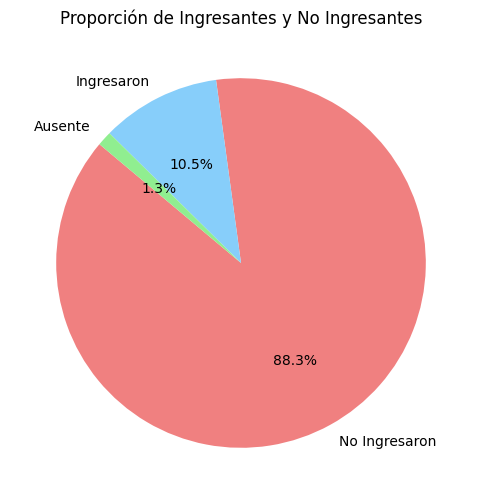

In [ ]:
#greafio pie ingresantes y no ingresantes
plt.figure(figsize=(10,6))
plt.pie(df_unmsm['clasificacion'].value_counts(), labels=['No Ingresaron', 'Ingresaron', 'Ausente'], autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue', 'lightgreen'], startangle=140)
plt.title('Proporción de Ingresantes y No Ingresantes')


Text(0.5, 1.0, 'Top 10 Carreras con Más Ingresantes')

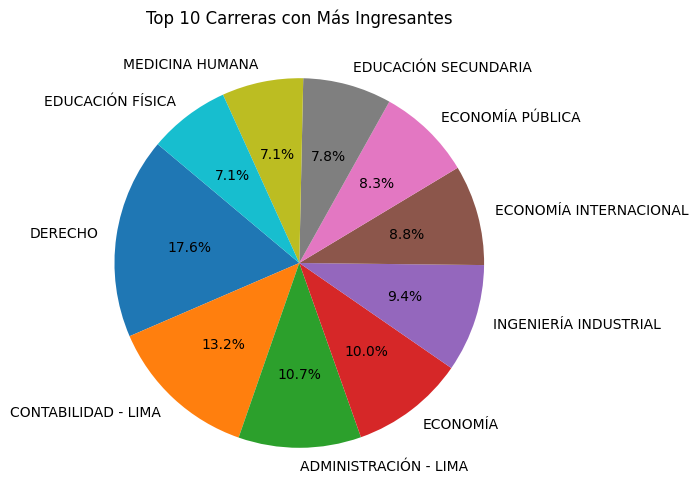

In [ ]:
top_10_carreras_ingresantes = df_unmsm[df_unmsm['clasificacion']==1]['escuela'].value_counts().head(10)

#grafico pies de las 10 carreras con mas ingresantes
plt.figure(figsize=(10,6))
plt.pie(top_10_carreras_ingresantes, labels=top_10_carreras_ingresantes.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Carreras con Más Ingresantes')      

In [ ]:
df_unmsm.to_excel("resultados_admision_unmsm_limpio.xlsx", index=False)

df_unmsm.head(20)

,codigo,nombre_apellido,escuela,puntaje,orden_merito,observacion,clasificacion
0,552493,"ANDAGUA GAMBOA, DALESKA MARTHA ESPERANZA",ADMINISTRACIÓN - HUARAL,560.625,9.0,ALCANZÓ VACANTE,1
1,570362,"BEZARES VILLAVERDE, JETLI",ADMINISTRACIÓN - HUARAL,923.750,1.0,ALCANZÓ VACANTE,1
2,591588,"FLORES PIMENTEL, LEONARDO CRISTOFER",ADMINISTRACIÓN - HUARAL,869.875,2.0,ALCANZÓ VACANTE,1
3,580332,"GARCIA CABELLO, PIEERS AXEL",ADMINISTRACIÓN - HUARAL,779.750,4.0,ALCANZÓ VACANTE,1
4,564185,"PALACIOS RAMÍREZ, JOSUÉ ANTONIO",ADMINISTRACIÓN - HUARAL,855.750,3.0,ALCANZÓ VACANTE,1
5,561061,"PROSOPIO ALARCON, JUAN PABLO",ADMINISTRACIÓN - HUARAL,530.375,NaN,NO ALACANZÓ VACANTE,0
6,564067,"QUISPE LLIUYA, JULIO RODRIGO",ADMINISTRACIÓN - HUARAL,724.500,5.0,ALCANZÓ VACANTE,1
7,563817,"RAFAEL SIMON, YASMIN MELANY",ADMINISTRACIÓN - HUARAL,595.250,8.0,ALCANZÓ VACANTE,1
8,572939,"SIFUENTES HURTADO, HUBELINDA",ADMINISTRACIÓN - HUARAL,612.000,7.0,ALCANZÓ VACANTE,1
9,569929,"SINARAHUA TAPULLIMA, ADOLFO HITLER",ADMINISTRACIÓN - HUARAL,534.750,10.0,ALCANZÓ VACANTE,1


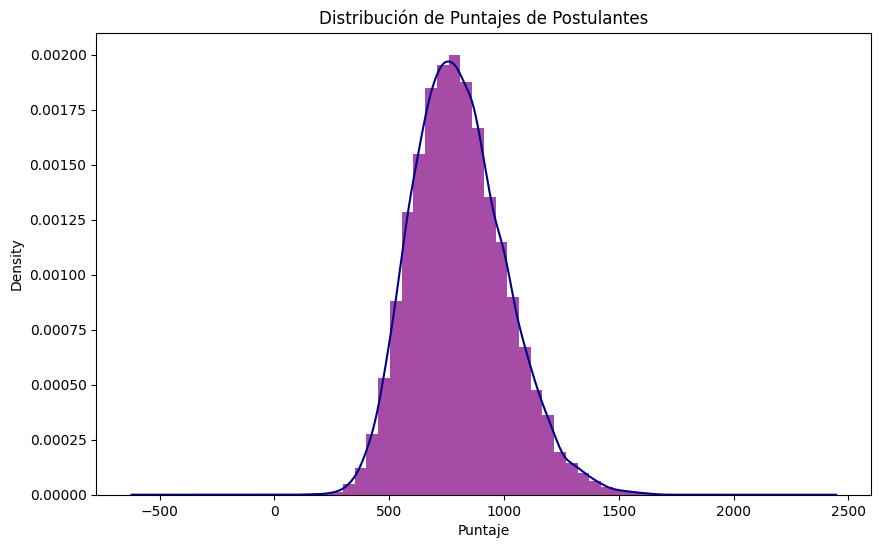

In [ ]:
histograma_puntajes = df_unmsm['puntaje'].hist(density=True, bins=30, figsize=(10,6), color='purple', alpha=0.7)
df_unmsm['puntaje'].plot.density(color='darkblue')
histograma_puntajes.set_xlabel('Puntaje')
histograma_puntajes.set_title('Distribución de Puntajes de Postulantes')
plt.show()

Text(0.5, 0, 'Orden de Mérito')

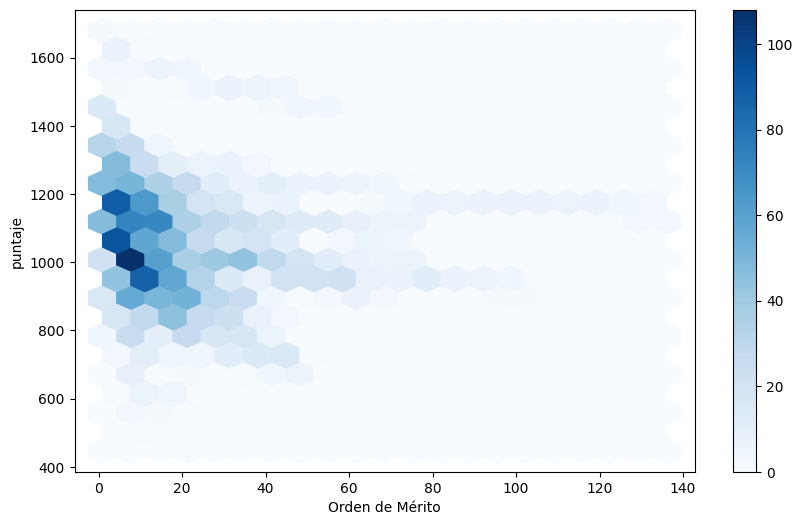

In [ ]:
ax = df_unmsm.plot.hexbin(x='orden_merito', y='puntaje', gridsize=20, cmap='Blues', figsize=(10,6), sharex=False)
ax.set_xlabel('Orden de Mérito')

In [ ]:
import pandas as pd

df = pd.read_csv('resultados_admision_unmsm.csv')

print("Total registros:", len(df))
print("\nTotal escuelas únicas:", df['escuela'].nunique())
print("\nLista completa de escuelas:")
print(df['escuela'].value_counts().to_string())